In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/default3.csv')

# Use index instead of step
for df in [df1]:
    df['index'] = df.index

In [20]:
def variable_span_ema(data: pd.Series, span_scale_factor: int = 1000) -> pd.Series:
    """
    Calculates an EMA with a span that increases with the index value (timestep).

    Args:
        data (pd.Series): The input data to smooth. Must have a numeric index (e.g., timesteps).
        span_scale_factor (int): Controls how quickly the span grows. A larger value
                                 means the span grows slower, resulting in less smoothing.
                                 The span at a given timestep `x` is roughly `x / span_scale_factor`.

    Returns:
        pd.Series: The smoothed data with the same index as the input.
    """
    if data.empty:
        return data

    # Get index and values for faster iteration
    index = data.index.to_numpy()
    values = data.to_numpy()
    
    # Initialize the output array and the first EMA value
    ema_values = np.zeros_like(values)
    ema_values[0] = values[0] 

    # Iterate from the second point onwards
    for i in range(1, len(values)):
        current_step = index[i]
        
        # 1. Calculate the variable span. Ensure it's at least 1.
        span = max(1.0, current_step / span_scale_factor)
        
        # 2. Convert span to alpha
        alpha = 2.0 / (span + 1.0)
        
        # 3. Apply the EMA formula
        ema_values[i] = alpha * values[i] + (1 - alpha) * ema_values[i-1]
        
    return pd.Series(ema_values, index=data.index)


In [15]:
def get_correlation_stats(col1, col2, log_scale=False):
    from scipy.stats import pearsonr, spearmanr
    filt_mdf = df1[~np.isnan(df1[col1]) & ~np.isnan(df1[col2])]
    if log_scale:
        filt_mdf = filt_mdf[filt_mdf[col1] > 0]
        filt_mdf = filt_mdf[filt_mdf[col2] > 0]
        filt_mdf[col1] = np.log(filt_mdf[col1])
        filt_mdf[col2] = np.log(filt_mdf[col2])
    corr_pearson, p_pearson = pearsonr(filt_mdf[col1], filt_mdf[col2])
    corr_spearman, p_spearman = spearmanr(filt_mdf[col1], filt_mdf[col2])
    return {
        'pearson': {
            'correlation': corr_pearson,
            'p-value': p_pearson
        },
        'spearman': {
            'correlation': corr_spearman,
            'p-value': p_spearman
        }
    }

{'pearson': {'correlation': 0.880724051688243, 'p-value': 0.0}, 'spearman': {'correlation': 0.8785175749408043, 'p-value': 0.0}}


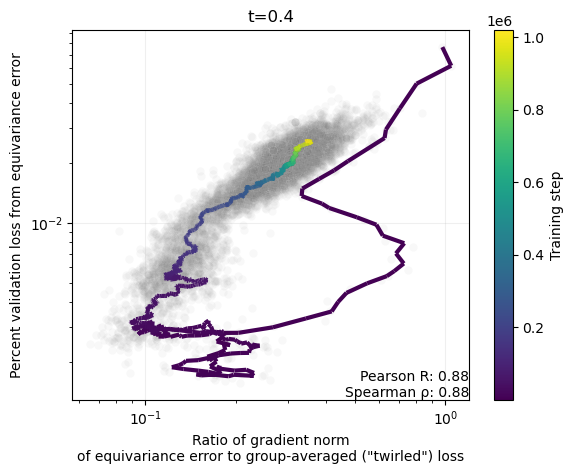

In [31]:
t = '0.4'

x_col = f'equiv/t={t}/grad_norm_ratio_equiv_over_mean'
y_col = f'equiv/t={t}/pct_loss_from_equiv_error'
cols = ['index', x_col, y_col]
df1[cols]
plot_df = df1[cols].dropna()

corr_stats = get_correlation_stats(x_col, y_col, log_scale=True)
print(corr_stats)

viridis_cmap = plt.get_cmap('viridis', df1['_step'].nunique())

smoothed_gn_df = plot_df.set_index('index').apply(variable_span_ema)
smoothed_gn_df['index'] = smoothed_gn_df.index

fig, ax = plt.subplots()
sns.scatterplot(
    data = plot_df,
    x = x_col,
    y = y_col,
    # hue = 'index',
    # palette = 'viridis',
    ax = ax,
    legend = False,
    alpha = 0.05,
    color = 'gray',
)
plt.grid(alpha = 0.2)

from matplotlib.collections import LineCollection
x = smoothed_gn_df[x_col].values
y = smoothed_gn_df[y_col].values
steps = smoothed_gn_df['index'].values

# Create segments: a list of (x, y) pairs
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 3. Create the LineCollection object
norm = plt.Normalize(steps.min(), steps.max())
lc = LineCollection(segments, cmap='viridis', norm=norm)

# Set the color of each segment based on the step value
lc.set_array(steps)
lc.set_linewidth(3)

# 4. Add the LineCollection to the axes
ax.add_collection(lc)

# 5. Add a colorbar to explain the line's color
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax)
cbar.set_label('Training step')


plt.xscale('log')
plt.yscale('log')

left, right = plt.xlim()
bottom, top = plt.ylim()

plt.ylabel('Percent validation loss from equivariance error')
plt.xlabel('Ratio of gradient norm\nof equivariance error to group-averaged ("twirled") loss')
plt.text( right, bottom, 
         f'Pearson R: {corr_stats["pearson"]["correlation"]:.2f}\nSpearman ρ: {corr_stats["spearman"]["correlation"]:.2f}', 
         ha='right', va='bottom')

# plt.savefig(f'prot-grad_norm-t={t}.png', dpi=300, bbox_inches='tight')
plt.title(f't={t}')
plt.show()
plt.close()

{'pearson': {'correlation': -0.3243562845197138, 'p-value': 4.603366251475592e-218}, 'spearman': {'correlation': -0.19241362197046694, 'p-value': 2.6322989658647166e-75}}


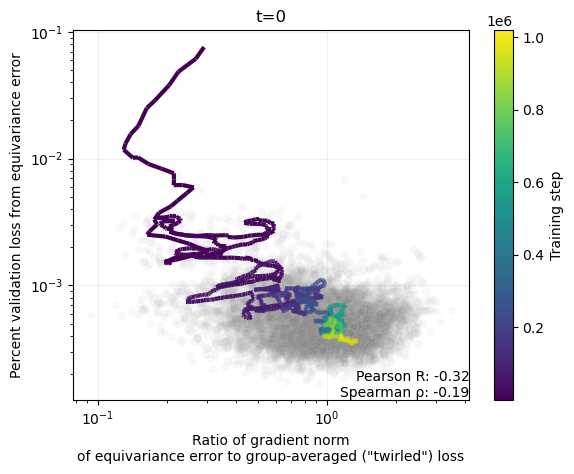

{'pearson': {'correlation': 0.5518443348398452, 'p-value': 0.0}, 'spearman': {'correlation': 0.5416129897175678, 'p-value': 0.0}}


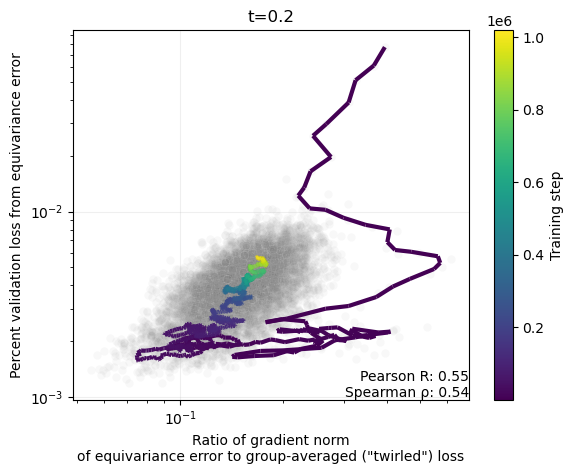

{'pearson': {'correlation': 0.880724051688243, 'p-value': 0.0}, 'spearman': {'correlation': 0.8785175749408043, 'p-value': 0.0}}


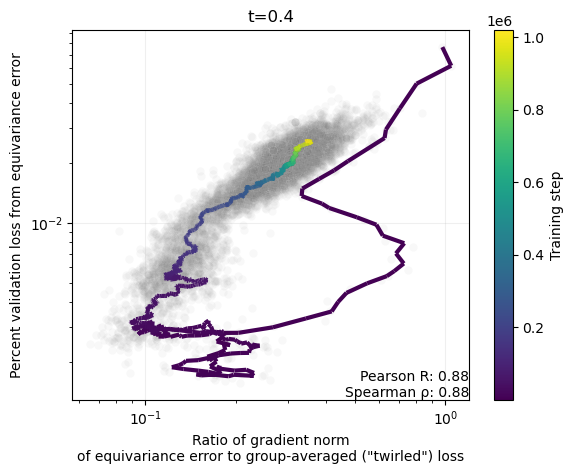

{'pearson': {'correlation': 0.8955092389335418, 'p-value': 0.0}, 'spearman': {'correlation': 0.8894842871799605, 'p-value': 0.0}}


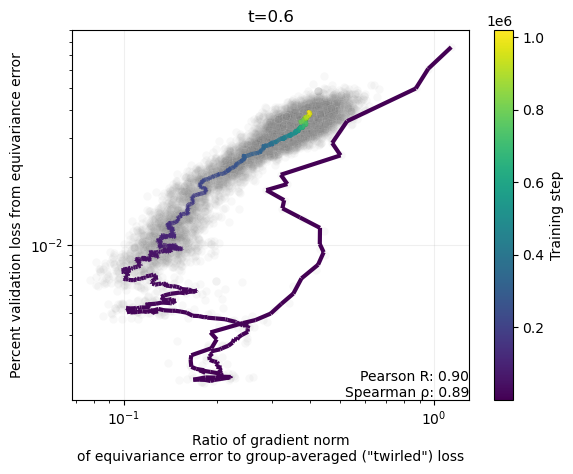

{'pearson': {'correlation': 0.411079660722296, 'p-value': 0.0}, 'spearman': {'correlation': 0.3438824939315556, 'p-value': 1.3398465315421154e-246}}


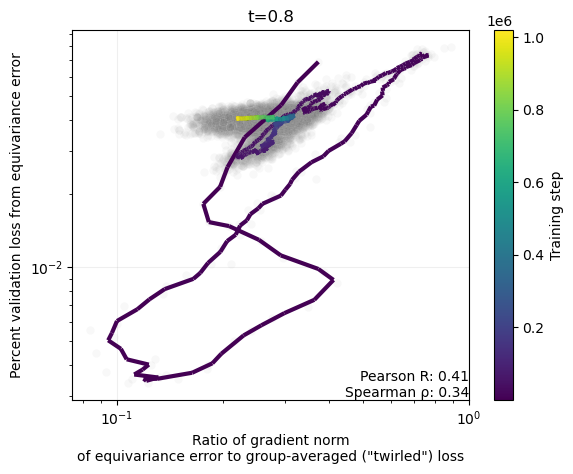

{'pearson': {'correlation': 0.8465677770750182, 'p-value': 0.0}, 'spearman': {'correlation': 0.8809421472182934, 'p-value': 0.0}}


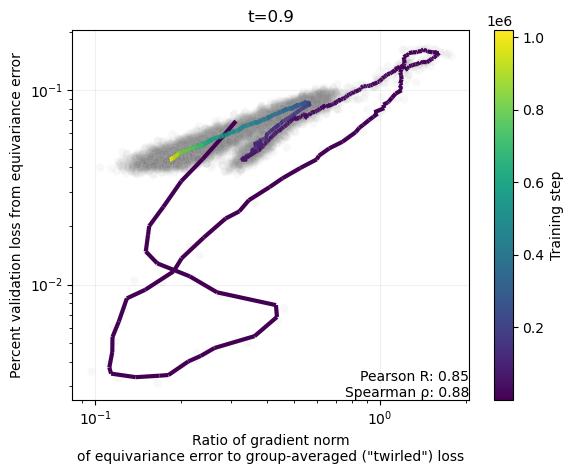

{'pearson': {'correlation': 0.8150099057627673, 'p-value': 0.0}, 'spearman': {'correlation': 0.8969749113001257, 'p-value': 0.0}}


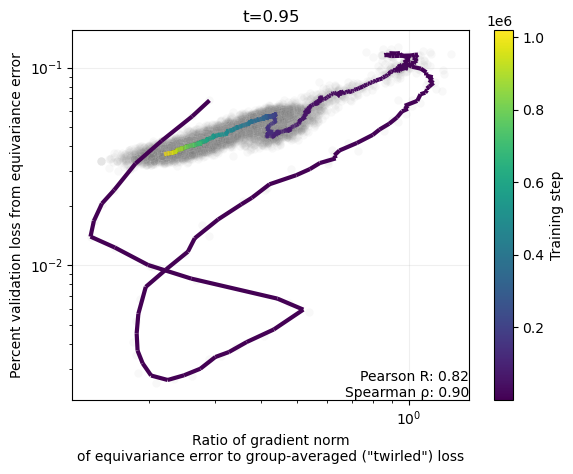

{'pearson': {'correlation': 0.8515383705521062, 'p-value': 0.0}, 'spearman': {'correlation': 0.7051301951969317, 'p-value': 0.0}}


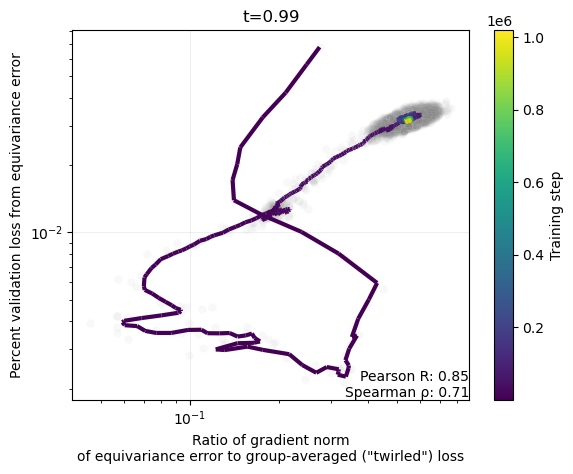

In [33]:
t = '0.4'

for t in ['0', '0.2', '0.4', '0.6', '0.8', '0.9', '0.95', '0.99']:

    x_col = f'equiv/t={t}/grad_norm_ratio_equiv_over_mean'
    y_col = f'equiv/t={t}/pct_loss_from_equiv_error'
    cols = ['index', x_col, y_col]
    df1[cols]
    plot_df = df1[cols].dropna()

    corr_stats = get_correlation_stats(x_col, y_col, log_scale=True)
    print(corr_stats)

    viridis_cmap = plt.get_cmap('viridis', df1['_step'].nunique())

    smoothed_gn_df = plot_df.set_index('index').apply(variable_span_ema)
    smoothed_gn_df['index'] = smoothed_gn_df.index

    fig, ax = plt.subplots()
    sns.scatterplot(
        data = plot_df,
        x = x_col,
        y = y_col,
        # hue = 'index',
        # palette = 'viridis',
        ax = ax,
        legend = False,
        alpha = 0.05,
        color = 'gray',
    )
    plt.grid(alpha = 0.2)

    from matplotlib.collections import LineCollection
    x = smoothed_gn_df[x_col].values
    y = smoothed_gn_df[y_col].values
    steps = smoothed_gn_df['index'].values

    # Create segments: a list of (x, y) pairs
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 3. Create the LineCollection object
    norm = plt.Normalize(steps.min(), steps.max())
    lc = LineCollection(segments, cmap='viridis', norm=norm)

    # Set the color of each segment based on the step value
    lc.set_array(steps)
    lc.set_linewidth(3)

    # 4. Add the LineCollection to the axes
    ax.add_collection(lc)

    # 5. Add a colorbar to explain the line's color
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax)
    cbar.set_label('Training step')


    plt.xscale('log')
    plt.yscale('log')

    left, right = plt.xlim()
    bottom, top = plt.ylim()

    plt.ylabel('Percent validation loss from equivariance error')
    plt.xlabel('Ratio of gradient norm\nof equivariance error to group-averaged ("twirled") loss')
    plt.text( right, bottom, 
            f'Pearson R: {corr_stats["pearson"]["correlation"]:.2f}\nSpearman ρ: {corr_stats["spearman"]["correlation"]:.2f}', 
            ha='right', va='bottom')

    import os
    plot_save_dir = 'prot-grad-norms/'
    os.makedirs(plot_save_dir, exist_ok=True)
    plt.savefig(
        os.path.join(plot_save_dir, f'prot-grad_norm-t={t}.png'), 
        dpi=300, 
        bbox_inches='tight'
    )
    plt.title(f't={t}')
    plt.show()
    plt.close()